In [542]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

* Criando funções para os relatórios finais e iniciais

In [543]:
def relatorio_inicial(df):
    """
    PRE AVALIACAO DA BASE
    """
    print("=" * 48)
    print(f"ETAPA 1 - AUDITORIA")
    print("=" * 48)
    
    print("\n[1] COLUNAS DA BASE:")
    print(df.columns.tolist())
    
    print("\n[2] INFO DA BASE:")
    df.info()
    
    print("\n[3] TIPOS DE DADOS (dtypes):")
    print(df.dtypes)
    
    print("\n[4] ESTATÍSTICAS DESCRITIVAS (Numéricas):")
    print(df.describe())

    '''print("\n[5] ESTATÍSTICAS DESCRITIVAS (Objetos/Texto): ")
    try:
        print(df.describe(include='object'))
    except ValueError:
        print("Não há colunas de texto nesta base.")'''
    
    print("\n[6] QUANTIDADE DE NULOS POR COLUNA:")
    print(df.isnull().sum())
     
    print("\n[8] PERCENTUAL DE NULOS (> 15%):")
    percentual_nulos = (df.isnull().sum() / len(df) * 100).round(1)
    print(percentual_nulos)
        
    print("\n[9] LINHAS COM VALORES NULOS:")
    qtd_nulos_linhas = df.isnull().any(axis=1).sum()
    print(f"Total de linhas com pelo menos um valor nulo: {qtd_nulos_linhas}")
    
    print("\n[10] TOTAL DE LINHAS DUPLICADAS:")
    total_duplicadas = df.duplicated().sum()
    print(f"Total: {total_duplicadas}")
    
    print("\n" + "=" * 48)
    print(f"FIM DO RELATÓRIO")
    print("=" * 48 + "\n")

def relatorio_final(df_original, df_atual):
    """
    RELATÓRIO FINAL DE AUDITORIA
    """
    registros_iniciais = df_original.shape[0]
    registros_finais = df_atual.shape[0]
    colunas_iniciais = df_original.shape[1]
    colunas_finais = df_atual.shape[1]

    print('=' * 48)
    print('      RELATÓRIO FINAL DE AUDITORIA')
    print('=' * 48)
    print(f'Registros iniciais:     {registros_iniciais:>6}')
    print(f'Registros finais:       {registros_finais:>6}')
    print(f'Registros removidos:    {registros_iniciais - registros_finais:>6}')
    print(f'Colunas originais:      {colunas_iniciais:>6}')
    print(f'Colunas finais:         {colunas_finais:>6}')
    print('=' * 48)
    print(f'Nulos restantes:        {df_atual.isnull().sum().sum():>6}')
    print(f'Duplicatas restantes:   {df_atual.duplicated().sum():>6}')
    print('=' * 48)

## Convertendo as bases em Dataframe

Concatenando base adicional de clientes à base original 2023-2024

In [544]:
canais = pd.read_csv('canais_venda.csv', sep=';', encoding='utf-8')
clientes = pd.read_csv('clientes.csv', sep=';', encoding='utf-8')
funcionarios = pd.read_csv('funcionarios.csv', sep=';', encoding='utf-8')
reservas = pd.read_csv('reservas.csv', sep=';', encoding='utf-8')
quartos = pd.read_csv('tipos_quarto.csv', sep=';', encoding='utf-8')
unidades = pd.read_csv('unidades.csv', sep=';', encoding='utf-8')

#Adicionando clientes novos às bases
clientes_novos=pd.read_csv('clientes_novos.csv', sep=';', encoding='utf-8')
df_concatenado_clientes = pd.concat([clientes, clientes_novos], ignore_index=True)

quartos_novos=pd.read_csv('tipos_quarto_novos.csv', sep=';', encoding='utf-8')
df_concatenado_quartos = pd.concat([quartos, quartos_novos], ignore_index=True)

funcionarios_novos=pd.read_csv('funcionarios_novos.csv', sep=';', encoding='utf-8')
df_concatenado_funcionarios = pd.concat([funcionarios, funcionarios_novos], ignore_index=True)

reservas_novos=pd.read_csv('reservas_novas.csv', sep=';', encoding='utf-8')
df_concatenado_reservas = pd.concat([reservas, reservas_novos], ignore_index=True)

unidades_total=pd.read_csv('unidades_novos.csv', sep=';', encoding='utf-8')
df_concatenado_unidades = pd.concat([unidades, unidades_total], ignore_index=True)

In [545]:
# df original - criando as cópias para o relatório final/arquivo

canais_original = canais.copy()

df_concatenado_unidades_original = df_concatenado_unidades.copy()
df_concatenado_clientes_original = df_concatenado_clientes.copy()
df_concatenado_funcionarios_original = df_concatenado_funcionarios.copy()
df_concatenado_quartos_original = df_concatenado_quartos.copy()
df_concatenado_reservas_original = df_concatenado_reservas.copy()

## Etapa 1 - Auditoria

* Aplica a função relatório inicial. Identifica inconsistências iniciais na base

In [546]:
#relatorio_inicial (canais)
#relatorio_inicial (funcionarios)
#relatorio_inicial(reservas)
#relatorio_inicial(quartos)
#relatorio_inicial(unidades)
#relatorio_inicial(clientes_novos)

## 2. Limpeza e tratamento

### 2.1 Base: funcionários

* Atualização e Correção da Base Salarial com map

In [547]:
novos_salarios = {
    9: '1870.00',
    10:'2314.00',
    14: '5480.00',
    37: '2950.00',
    43:'5600.00',
    92:'8600.00',
    104:'2890.00',
    11:'2800.00',
    26:'2150.00',
}

df_concatenado_funcionarios.loc[df_concatenado_funcionarios['id_funcionario'].isin(novos_salarios), 'salario'] = df_concatenado_funcionarios['id_funcionario'].map(novos_salarios)

In [548]:
df_concatenado_funcionarios['departamento'].value_counts()

departamento
Governança             33
Manutenção             24
Segurança              20
Financeiro             15
Recepção               15
Alimentos e Bebidas    13
Gov.                    8
Administração           8
A&B                     5
Admin.                  1
Operações               1
operações               1
Name: count, dtype: int64

In [549]:
df_concatenado_funcionarios['departamento'].value_counts()

mapa = {
    'Gov.':                     'Governança',
    'Admin.':  'Administração'             ,
    'operações' :'Operações',
    'A&B': 'Alimentos e Bebidas'

}

df_concatenado_funcionarios['departamento'] = df_concatenado_funcionarios['departamento'].map(mapa).fillna(df_concatenado_funcionarios['departamento'])#joga as informações do dicionario mapa no df. filne mantem os valores corretos que não precisam de substituição

print('Após mapeamento:\n')
print(sorted(df_concatenado_funcionarios['departamento'].unique()))

Após mapeamento:

['Administração', 'Alimentos e Bebidas', 'Financeiro', 'Governança', 'Manutenção', 'Operações', 'Recepção', 'Segurança']


* Ajustando e padronizando strings nas colunas

In [550]:
df_concatenado_funcionarios['salario'] = df_concatenado_funcionarios['salario'].str.replace('"', '', regex=False).str.replace("'","", regex=False).str.replace(",",".", regex=False)

- Convergindo colunas com datas para Datetime
- Aplicando função para correção da coluna salário

In [551]:
df_concatenado_funcionarios['data_admissao'] = pd.to_datetime(
    df_concatenado_funcionarios['data_admissao'],
    format='mixed',
    errors='coerce'
)

def corrigir_valor(x):
    if pd.isna(x):
        return x
    x = str(x)
    if x.count('.') == 2:
        x = x.replace('.', '', 1)
    return x

df_concatenado_funcionarios['salario'] = df_concatenado_funcionarios['salario'].apply(corrigir_valor)

df_concatenado_funcionarios['salario'] = pd.to_numeric(df_concatenado_funcionarios['salario'], errors='coerce')

df_concatenado_funcionarios[df_concatenado_funcionarios['salario'].isna()][['nome', 'salario']]

novos_salarios = {
    142: 7850.00    
}

df_concatenado_funcionarios.loc[df_concatenado_funcionarios['id_funcionario'].isin(novos_salarios), 'salario'] = df_concatenado_funcionarios['id_funcionario'].map(novos_salarios)

df_concatenado_funcionarios['cargo'] = df_concatenado_funcionarios['cargo'].str.upper()

df_concatenado_funcionarios.head(50)  

,id_funcionario,id_unidade,nome,cargo,departamento,salario,data_admissao
0,1,1,Gabriela Lima,AUXILIAR DE LIMPEZA,Governança,2139.0,2020-10-05
1,2,1,Abel Correia,SEGURANÇA,Segurança,1746.0,2021-12-29
2,3,1,Sara Teixeira,ANALISTA FINANCEIRO,Financeiro,5356.0,2022-03-01
3,4,1,Julia Monteiro,AUXILIAR DE LIMPEZA,Governança,2070.0,2019-06-10
4,5,1,Daniela Ramos,AUXILIAR DE LIMPEZA,Governança,1572.0,2018-10-16
5,6,1,Lucas Souza,AUXILIAR DE LIMPEZA,Governança,1955.0,2024-02-01
6,7,1,Wilson Duarte,RECEPCIONISTA,Recepção,1906.0,2023-03-24
7,8,1,Nicolas Cunha,RECEPCIONISTA,Recepção,2417.0,2019-07-02
8,9,1,Bruno Costa,AUXILIAR DE LIMPEZA,Governança,1870.0,2021-11-02
9,10,1,Bruno Costa,MANUTENÇÃO,Manutenção,2314.0,2022-11-28


### 2.2 base: Reservas

* correção das diárias
* correção da avaliação dos hóspedes

Considerando a necessidade de métricas posteriores e decisão do cliente em
manter nulos valores iguais a 0, optou-se por manter valores nulos/impossíveis
como não avaliados. 

Contudo, vale alertar novamente que os valores não informados somam-se à 
646 pontos elevando-se à 13.9% do total de avaliações.


* Inclusão e correção de valores fornecidos pelo cliente com função MAP.

* Correção do sinal negativo na quantidade de hóspedes. 

In [552]:
relatorio_inicial(df_concatenado_reservas)

ETAPA 1 - AUDITORIA

[1] COLUNAS DA BASE:
['id_reserva', 'id_unidade', 'id_tipo_quarto', 'id_cliente', 'id_canal', 'data_checkin', 'data_checkout', 'qtd_diarias', 'num_hospedes', 'avaliacao_hospede', 'status_reserva', 'forma_pagamento']

[2] INFO DA BASE:
<class 'pandas.DataFrame'>
RangeIndex: 4664 entries, 0 to 4663
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_reserva         4664 non-null   int64  
 1   id_unidade         4664 non-null   int64  
 2   id_tipo_quarto     4664 non-null   int64  
 3   id_cliente         4664 non-null   int64  
 4   id_canal           4455 non-null   float64
 5   data_checkin       4664 non-null   str    
 6   data_checkout      4664 non-null   str    
 7   qtd_diarias        4664 non-null   int64  
 8   num_hospedes       4664 non-null   int64  
 9   avaliacao_hospede  4018 non-null   float64
 10  status_reserva     4664 non-null   str    
 11  forma_pagamento    

In [553]:
novos_valores = {
    728: 7, 955: 4, 1134: 3, 1152: 2,
    1448: 6, 1581: 4, 2312: 4, 2384: 2,
    2509: 1, 4030: 1, 3472: 1, 3505: 1, 
    3838: 1, 4048: 1
}
novas_avaliacoes = {
    37: 1, 902: 1, 2073: 1, 933: 3, 1718: 3, 2167: 3,
    3541: 1, 2874: 1, 4127: 1, 4088: 3
}

correcao_novos_hospedes = {
    568: 1, 675: 2, 903: 1, 1201: 2, 1883: 2,
    2427: 2, 4463: 1, 4506: 2, 4040: 2, 2687: 2,
}

ids_hospedes = list(correcao_novos_hospedes.keys())
df_concatenado_reservas.loc[
    df_concatenado_reservas['id_reserva'].isin(ids_hospedes), 'num_hospedes'
] = df_concatenado_reservas['id_reserva'].map(correcao_novos_hospedes)

ids_avaliacoes = list(novas_avaliacoes.keys())

df_concatenado_reservas.loc[
    df_concatenado_reservas['id_reserva']
    .isin(ids_avaliacoes),
    'avaliacao_hospede'
] = df_concatenado_reservas['id_reserva'].map(novas_avaliacoes)

ids_valores = list(novos_valores.keys())

df_concatenado_reservas.loc[
    df_concatenado_reservas['id_reserva']
    .isin(ids_valores),
    'qtd_diarias'] = df_concatenado_reservas['id_reserva'].map(novos_valores)

df_filtrado = df_concatenado_reservas[df_concatenado_reservas['id_reserva'].isin(ids_valores)]

print((df_concatenado_reservas['num_hospedes'] < 0).sum())
print((df_concatenado_reservas['qtd_diarias'] < 0).sum())
print((df_concatenado_reservas['id_canal'] == -1).sum())

0
0
0


In [554]:
df_concatenado_reservas[df_concatenado_reservas['avaliacao_hospede'].isnull()]

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
7,8,4,4,33,3.0,2023-08-26,2023-09-02,7,2,NaN,no-show,Dinheiro
13,14,4,3,68,3.0,2024-03-07,2024-03-11,4,3,NaN,cancelada,Dinheiro
14,15,6,2,173,1.0,2024-07-20,2024-07-23,3,1,NaN,cancelada,Transferência
35,36,11,1,259,4.0,2023-03-26,2023-03-29,3,1,NaN,cancelada,Cartão de Crédito
40,41,9,3,74,1.0,2023-12-03,2023-12-09,6,3,NaN,confirmada,Cartão de Débito
...,...,...,...,...,...,...,...,...,...,...,...,...
4646,3928,11,1,175,3.0,2025-03-20,2025-03-21,1,2,NaN,confirmada,Transferência
4648,3844,11,3,33,4.0,2026-01-26,2026-01-28,2,3,NaN,confirmada,Transferência
4649,2835,4,2,36,3.0,2025-07-05,2025-07-07,2,1,NaN,confirmada,Dinheiro
4651,4172,3,1,102,2.0,2025-04-01,2025-04-02,1,4,NaN,CONFIRMADA,Dinheiro


* Identifica as duplicidades

* Refinamento e inspeção visual com a função *value.counts()*

In [555]:
#print('--- ativo ---')
#print(df_concatenado_reservas['id_reserva'].value_counts())

#print('--- ativo ---')
#print(df_concatenado_reservas['id_unidade'].value_counts())

#print('--- ativo ---')
#print(df_concatenado_reservas['id_tipo_quarto'].value_counts())

#print('--- ativo ---')
#print(df_concatenado_reservas['id_cliente'].value_counts())

#print('--- ativo ---')
#print(df_concatenado_reservas['status_reserva'].value_counts())

#print('--- ativo ---')
#print(df_concatenado_reservas['forma_pagamento'].value_counts())


* Remove as duplicidades na coluna Id reserva

* Resolve a duplicidades dos ids 
(2486...4560) através da função Keep, condição First, que elimina
a segunda ocorrência.

In [556]:
shape_inicial = df_concatenado_reservas.shape[0]

df_concatenado_reservas = df_concatenado_reservas.drop_duplicates(
    subset=['id_reserva'], 
    keep='first'
)

shape_final = df_concatenado_reservas.shape[0]

print(f'Registros iniciais: {shape_inicial}')
print(f'Registros finais: {shape_final}')
print(f'{shape_inicial - shape_final} registros duplicados apagados')

Registros iniciais: 4664
Registros finais: 4649
15 registros duplicados apagados


* Remove com a f=dropna as linhas sem 'id_canal' informado

* Converte a coluna 'id' em formato int

* Força a conversão da coluna 'avaliação' em formato numérico (incluindo Nan)

In [557]:

df_concatenado_reservas = df_concatenado_reservas.dropna(subset=['id_canal'])

df_concatenado_reservas['id_canal'] = df_concatenado_reservas['id_canal'].astype(int)

df_concatenado_reservas['avaliacao_hospede'] = pd.to_numeric(df_concatenado_reservas['avaliacao_hospede'], errors='coerce')


* Padronizando strings nas colunas **status da reserva** e **forma de pagamento**

In [558]:
#print('\n--- nomes com espaço nas bordas ---')

#mascara = df_concatenado_reservas['status_reserva'].str.startswith(' ') | df_concatenado_reservas['status_reserva'].str.endswith(' ')
#mascara = df_concatenado_reservas['forma_pagamento'].str.startswith(' ') | df_concatenado_reservas['forma_pagamento'].str.endswith(' ')

#df_concatenado_reservas['forma_pagamento'].value_counts()

#print(df_concatenado_reservas.loc[mascara, 'status_reserva'].tolist())
#print(df_concatenado_reservas.loc[mascara, 'forma_pagamento'].tolist())

In [559]:
df_concatenado_reservas['status_reserva'] = df_concatenado_reservas['status_reserva'].str.strip().str.upper()

df_concatenado_reservas['forma_pagamento'] = df_concatenado_reservas['forma_pagamento'].str.strip().str.upper()

df_concatenado_reservas[['forma_pagamento', 'status_reserva']].head(10)
#df_concatenado_reservas[['forma_pagamento', 'status_reserva']].tail(10)


,forma_pagamento,status_reserva
0,CARTÃO DE CRÉDITO,CONFIRMADA
1,PIX,CONCLUÍDA
2,CARTÃO DE CRÉDITO,CONCLUÍDA
3,PIX,CANCELADA
4,TRANSFERÊNCIA,CONFIRMADA
5,TRANSFERÊNCIA,CONFIRMADA
6,DINHEIRO,CONFIRMADA
7,DINHEIRO,NO-SHOW
8,DINHEIRO,CONCLUÍDA
9,PIX,CONFIRMADA


* Padronização de strings na coluna STATUS utilizando a função Map

In [560]:
mapa_status = {
    'CONFIRMADA': 'CONFIRMADA',
    'CONF.': 'CONFIRMADA',
    'CANCELADA': 'CANCELADA',
    'CANCEL.': 'CANCELADA',
    'CONCLUÃDA': 'CONCLUÍDA',
    'CONCLUIDA': 'CONCLUÍDA',
    'NO-SHOW': 'NO-SHOW'
}

df_concatenado_reservas['status_reserva'] = df_concatenado_reservas['status_reserva'].map(mapa_status)

print(df_concatenado_reservas['status_reserva'].value_counts())

status_reserva
CONFIRMADA    2961
CANCELADA      627
NO-SHOW        221
CONCLUÍDA       28
Name: count, dtype: int64


* Padronização de strings na coluna FORMA DE PAGAMENTO
com a função *map*

In [561]:
mapa_pagamento = {
    'DINHEIRO': 'DINHEIRO',
    'CASH': 'DINHEIRO',

    'PIX': 'PIX',

    'CARTÃO DE DÉBITO': 'CARTÃO DE DÉBITO',
    'CARTAO DEBITO': 'CARTÃO DE DÉBITO',
    'CD': 'CARTÃO DE DÉBITO',
    'DÉBITO': 'CARTÃO DE DÉBITO',

    'CARTÃO DE CRÉDITO': 'CARTÃO DE CRÉDITO',
    'CARTAO CREDITO': 'CARTÃO DE CRÉDITO',
    'C. CRÉDITO': 'CARTÃO DE CRÉDITO',
    'CRED': 'CARTÃO DE CRÉDITO',
    'CC': 'CARTÃO DE CRÉDITO',

    'TRANSFERÊNCIA': 'TRANSFERÊNCIA',
    'TRANSFERENCIA': 'TRANSFERÊNCIA',
    'TED': 'TRANSFERÊNCIA'
}

df_concatenado_reservas['forma_pagamento'] = df_concatenado_reservas['forma_pagamento'].map(mapa_pagamento)

print(df_concatenado_reservas['forma_pagamento'].value_counts())

forma_pagamento
DINHEIRO             938
PIX                  885
CARTÃO DE DÉBITO     882
TRANSFERÊNCIA        866
CARTÃO DE CRÉDITO    852
Name: count, dtype: int64


* Tratando nulos: recurso *fillna()* para o preenchimento de valores não informados

* Decisão de não exclusão devido ao tipo de dado (cadastro de clientes e reservas)

* Tratamento dos id_canais apenas válidos para resolver a integração entre base e SQL.

In [562]:
df_concatenado_reservas['id_canal'] = (
    df_concatenado_reservas['id_canal']
    .fillna(-1)
)

df_concatenado_reservas['forma_pagamento'] = (
    df_concatenado_reservas['forma_pagamento']
    .fillna('NÃO INFORMADO')
)

df_concatenado_reservas['status_reserva'] = (
    df_concatenado_reservas['status_reserva']
    .fillna('NÃO INFORMADO')
)

ids_validos_canais = canais['id_canal'].unique()
df_concatenado_reservas = df_concatenado_reservas[df_concatenado_reservas['id_canal'].isin(ids_validos_canais)]

#ids_validos_canais
print(df_concatenado_reservas.isnull().sum())
#print(df_concatenado_reservas['id_canal'].dtype)
#print(df_concatenado_reservas['id_canal'].unique())

id_reserva             0
id_unidade             0
id_tipo_quarto         0
id_cliente             0
id_canal               0
data_checkin           0
data_checkout          0
qtd_diarias            0
num_hospedes           0
avaliacao_hospede    609
status_reserva         0
forma_pagamento        0
dtype: int64


Corrige a coluna de avaliação do hospede

* Decisão: o recurso fillna impede que o pandas calcule métrica posteriormente

* Procedimento: pd.to_numeric para alternar a coluna de avaliação ao formato numérico

* Resultado esperado: Pandas ignore valores nulos e permita análise métrica de avaliações.
Coluna avaliação retorna a float.


In [563]:
df_concatenado_reservas['avaliacao_hospede'] = pd.to_numeric(
    df_concatenado_reservas['avaliacao_hospede'], 
    errors='coerce')

df_concatenado_reservas['avaliacao_hospede'].info()

#print(df_concatenado_reservas['avaliacao_hospede'].isnull().sum())
#print(df_concatenado_reservas['avaliacao_hospede'].mean().round(2))

<class 'pandas.Series'>
Index: 4440 entries, 0 to 4663
Series name: avaliacao_hospede
Non-Null Count  Dtype  
--------------  -----  
3831 non-null   float64
dtypes: float64(1)
memory usage: 69.4 KB


* Corrigindo dtype das colunas

* Corrige a coluna id_canal em formato INT

* Coluna de datas de *STR* para *Datetime*


In [564]:
df_concatenado_reservas['id_canal'] = df_concatenado_reservas['id_canal'].astype(int)

In [565]:
df_concatenado_reservas['data_checkin'] = pd.to_datetime(
    df_concatenado_reservas['data_checkin'],
    format='mixed',
    errors='coerce'
)
df_concatenado_reservas['data_checkout'] = pd.to_datetime(
    df_concatenado_reservas['data_checkout'],
    format='mixed',
    errors='coerce'
)

print(df_concatenado_reservas[['data_checkin', 'data_checkout']].head(10))
print("\n")
print(df_concatenado_reservas[['data_checkin', 'data_checkout']].isnull().sum())

  data_checkin data_checkout
0   2024-04-28    2024-04-30
1   2023-09-28    2023-10-01
2   2023-08-01    2023-08-06
3   2023-02-18    2023-02-21
4   2023-01-12    2023-01-19
5   2024-04-28    2024-05-03
6   2023-04-19    2023-04-24
7   2023-08-26    2023-09-02
8   2024-04-04    2024-04-08
9   2023-07-02    2023-07-04


data_checkin     0
data_checkout    0
dtype: int64


* Tratamento dos valores negativos nas colunas: *id_canal, qtd_diarias e num_hospedes*

* Aplicando filtro simples para identificar valores negativos

In [566]:
negativos_diarias = df_concatenado_reservas[df_concatenado_reservas['qtd_diarias'] < 0]
negativos_hospedes = df_concatenado_reservas[df_concatenado_reservas['num_hospedes'] < 0]

print(negativos_diarias)
print(negativos_hospedes)

Empty DataFrame
Columns: [id_reserva, id_unidade, id_tipo_quarto, id_cliente, id_canal, data_checkin, data_checkout, qtd_diarias, num_hospedes, avaliacao_hospede, status_reserva, forma_pagamento]
Index: []
Empty DataFrame
Columns: [id_reserva, id_unidade, id_tipo_quarto, id_cliente, id_canal, data_checkin, data_checkout, qtd_diarias, num_hospedes, avaliacao_hospede, status_reserva, forma_pagamento]
Index: []


Aplicação de filtros finais de consistência 

* Filtros de Regra de Negócios:

- `num_hospedes`: Mantém apenas reservas entre *1 e 20 hóspedes*
- `qtd_diarias`: Mantém apenas estadias entre **1 e 60 dias*

* Contagem de Nulos Intencionais: Verifica quantos registros ficaram sem `avaliacao_hospede` (mantidos como `NaN` propositalmente para não distorcer o cálculo de médias futuras).

In [567]:
antes = df_concatenado_reservas.shape[0]

df_concatenado_reservas = df_concatenado_reservas[
    df_concatenado_reservas['num_hospedes'].between(1, 20) &
    df_concatenado_reservas['qtd_diarias'].between(1, 60)
]

total_nulos = df_concatenado_reservas['avaliacao_hospede'].isnull().sum()

print(f'Valores removidos (fora do intervalo): {antes - df_concatenado_reservas.shape[0]}')
print(f'Shape atual: {df_concatenado_reservas.shape}')
print(f"Total de avaliações nulas: {total_nulos}")

Valores removidos (fora do intervalo): 0
Shape atual: (4440, 12)
Total de avaliações nulas: 609


* Aplica as funções de relatórios. Cria o comparativo de execuções

In [568]:
df_atual = df_concatenado_reservas
df_original = df_concatenado_reservas_original

relatorio_final(df_original, df_atual)

      RELATÓRIO FINAL DE AUDITORIA
Registros iniciais:       4664
Registros finais:         4440
Registros removidos:       224
Colunas originais:          12
Colunas finais:             12
Nulos restantes:           609
Duplicatas restantes:        0


### 2.3 base: Clientes

- Coluna Faixa Etária em formato STR
- Presença de valores nulos na mesma coluna
- Erros de grafia nas colunas 'Estado Origem', 'Pagamento' e Tipo Cliente
- Duplicidade do ID Cliente n° 47

Por decisão do cliente os registros (total 29) vazios nas colunas 'faixa_etária'
são mantidos como nulos (Nan) e não 0.

In [569]:
df_concatenado_clientes_original = df_concatenado_clientes.copy()

relatorio_inicial(df_concatenado_clientes_original)

ETAPA 1 - AUDITORIA

[1] COLUNAS DA BASE:
['id_cliente', 'nome', 'cidade_origem', 'estado_origem', 'faixa_etaria', 'tipo_cliente']

[2] INFO DA BASE:
<class 'pandas.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id_cliente     321 non-null    int64
 1   nome           321 non-null    str  
 2   cidade_origem  321 non-null    str  
 3   estado_origem  321 non-null    str  
 4   faixa_etaria   290 non-null    str  
 5   tipo_cliente   321 non-null    str  
dtypes: int64(1), str(5)
memory usage: 15.2 KB

[3] TIPOS DE DADOS (dtypes):
id_cliente       int64
nome               str
cidade_origem      str
estado_origem      str
faixa_etaria       str
tipo_cliente       str
dtype: object

[4] ESTATÍSTICAS DESCRITIVAS (Numéricas):
       id_cliente
count  321.000000
mean   160.146417
std     92.592557
min      1.000000
25%     80.000000
50%    160.000000
75%    240.000000
max  

Refinamento da auditoria com a função *value.counts()* e filtro negativo

* Inconsistências de grafias stings
* Relação inconsistênte entre Estado de origem e cidade de origem divergente

In [570]:

#display(df_concatenado_clientes[df_concatenado_clientes['id_cliente'] < 0])

print("\n--- Estado de Origem ---")
#display(df_concatenado_clientes['estado_origem'].value_counts())

print("\n--- Faixa Etária ---")
#display(df_concatenado_clientes['faixa_etaria'].value_counts())

print("\n--- Tipo de Cliente ---")
#display(df_concatenado_clientes['tipo_cliente'].value_counts())

print("\n--- Cidade de Origem ---")
#display(df_concatenado_clientes['cidade_origem'].value_counts())

#display(df_concatenado_clientes['id_cliente'].value_counts())
#display(df_concatenado_clientes['nome'].value_counts())


--- Estado de Origem ---

--- Faixa Etária ---

--- Tipo de Cliente ---

--- Cidade de Origem ---


* Coluna Nome: Padronização dos strings

In [571]:
df_concatenado_clientes['nome'] = df_concatenado_clientes['nome'].str.strip().str.title()

df_concatenado_clientes['nome']

0             Otavio Reis
1           Larissa Sousa
2          Tatiana Coelho
3           Wilson Duarte
4           Gabriela Lima
              ...        
316    Priscila Guimarães
317       Rodrigo Vasques
318        Sabrina Leitão
319        Thiago Bicalho
320        Vivian Lacerda
Name: nome, Length: 321, dtype: str

* Padroniza a grafia das colunas estados e cidades com upper e strip
* Resolve a correspodência entre cidade-Estados.

In [572]:
df_concatenado_clientes['cidade_origem'] = (
    df_concatenado_clientes['cidade_origem']
    .str.strip()
    .str.upper()
)

mapa_cidade_estado = {
    'FORTALEZA': 'CE',
    'SÃO PAULO': 'SP',
    'RECIFE': 'PE',
    'CURITIBA': 'PR',
    'BRASÍLIA': 'DF',
    'BELO HORIZONTE': 'MG',
    'SALVADOR': 'BA',
    'RIO DE JANEIRO': 'RJ',
    'NITERÓI': 'RJ',
    'PORTO ALEGRE': 'RS',
    'LISBOA': 'EX',
    'BUENOS AIRES': 'EX',
    'NOVA YORK': 'EX',
    'MIAMI': 'EX',
}

df_concatenado_clientes['estado_origem'] = (
    df_concatenado_clientes['estado_origem']
    .str.strip()
    .str.upper()
)

df_concatenado_clientes['estado_origem'] = df_concatenado_clientes['cidade_origem'].map(mapa_cidade_estado)

#print(df_concatenado_clientes[['cidade_origem', 'estado_origem']].isnull().sum())

#df_concatenado_clientes['cidade_origem'].value_counts()


Coluna 'Tipo_cliente' - padronização dos strings

In [573]:
df_concatenado_clientes['tipo_cliente'] = df_concatenado_clientes['tipo_cliente'].str.strip().str.upper()

mapa_tipo_cliente = {
    'CORPORATIVO': 'CORPORATIVO',
    'PF': 'PESSOA FÍSICA',
    'PJ': 'PESSOA JURÍDICA',
    'PESSOA FISICA': 'PESSOA FÍSICA',
    'PESSOA FÍSICA': 'PESSOA FÍSICA',
    'PESSOA JURÍDICA': 'PESSOA JURÍDICA',
}

df_concatenado_clientes['tipo_cliente'] = df_concatenado_clientes['tipo_cliente'].map(mapa_tipo_cliente)

print(df_concatenado_clientes['tipo_cliente'].value_counts())

tipo_cliente
PESSOA FÍSICA      150
CORPORATIVO        146
PESSOA JURÍDICA     25
Name: count, dtype: int64


* Padronização dos strings na coluna 'cidade_origem'

In [574]:
df_concatenado_clientes['cidade_origem'] = (
    df_concatenado_clientes['cidade_origem']
    .str.strip()
    .str.title()
)

df_concatenado_clientes['cidade_origem']

0           São Paulo
1            Curitiba
2      Rio De Janeiro
3            Brasília
4      Rio De Janeiro
            ...      
316            Lisboa
317    Rio De Janeiro
318          Brasília
319    Belo Horizonte
320      Buenos Aires
Name: cidade_origem, Length: 321, dtype: str

* Resolvendo a duplicidade de ID - n° 47

* Com base na recomendação do cliente, atribuiumos o ID 401 ao cliente Carlos Neto.

In [575]:
df_concatenado_clientes['id_cliente'].value_counts()

df_concatenado_clientes.loc[
    (df_concatenado_clientes['id_cliente'] == 47)
    & (df_concatenado_clientes['nome'] == 'Carlos Neto'),
    'id_cliente'] = 401

print(df_concatenado_clientes['id_cliente'].value_counts())
print(df_concatenado_clientes[df_concatenado_clientes['id_cliente'].isin([47, 401])])

id_cliente
1      1
2      1
3      1
4      1
5      1
      ..
316    1
317    1
318    1
319    1
320    1
Name: count, Length: 321, dtype: int64
     id_cliente           nome cidade_origem estado_origem faixa_etaria  \
46           47  Wesley Araujo        Recife            PE          65+   
300         401    Carlos Neto       Niterói            RJ        36-45   

      tipo_cliente  
46   PESSOA FÍSICA  
300    CORPORATIVO  


In [576]:
df_atual = df_concatenado_clientes

relatorio_final(df_concatenado_clientes_original, df_atual)

      RELATÓRIO FINAL DE AUDITORIA
Registros iniciais:        321
Registros finais:          321
Registros removidos:         0
Colunas originais:           6
Colunas finais:              6
Nulos restantes:            31
Duplicatas restantes:        0


### 2.3 base Canais Venda

* Padronização da grafia do nome do canal

* Remoção do símbolo de percentual

* Altera o tipo de coluna string para INT


In [577]:
#relatorio_inicial(canais_original)

canais['nome_canal'] = canais['nome_canal'].str.strip().str.upper()

canais['comissao_pct'] = (
    canais['comissao_pct']
    .astype(str)
    .str.replace('%', '', regex=False)
)

canais['comissao_pct'] = pd.to_numeric(canais['comissao_pct'], errors='coerce')

### 2.4 base Unidades: 

* Padronização das grafias nas colunas região e categoria do hotel
* Corrige inconsistências na categoria de cada unidade


In [578]:
relatorio_inicial(df_concatenado_unidades_original)

df_concatenado_unidades['regiao'] = (
    df_concatenado_unidades['regiao']
    .replace('CAP', 'Capital')
    .str.strip()                
    .str.title()                
)

df_concatenado_unidades['categoria_hotel'] = (
    df_concatenado_unidades['categoria_hotel']
    .str.lower()                           
    .str.replace('cinco', '5')             
    .str.replace('três', '3')           
    .str.replace('*', ' estrelas')
    .str.title()
)

df_concatenado_unidades.tail(15)

ETAPA 1 - AUDITORIA

[1] COLUNAS DA BASE:
['id_unidade', 'nome_unidade', 'cidade', 'regiao', 'categoria_hotel', 'num_quartos_total']

[2] INFO DA BASE:
<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_unidade         13 non-null     int64  
 1   nome_unidade       13 non-null     str    
 2   cidade             13 non-null     str    
 3   regiao             13 non-null     str    
 4   categoria_hotel    13 non-null     str    
 5   num_quartos_total  11 non-null     float64
dtypes: float64(1), int64(1), str(4)
memory usage: 756.0 bytes

[3] TIPOS DE DADOS (dtypes):
id_unidade             int64
nome_unidade             str
cidade                   str
regiao                   str
categoria_hotel          str
num_quartos_total    float64
dtype: object

[4] ESTATÍSTICAS DESCRITIVAS (Numéricas):
       id_unidade  num_quartos_total
count    13.

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5 Estrelas,80.0
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4 Estrelas,120.0
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3 Estrelas,60.0
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4 Estrelas,45.0
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3 Estrelas,50.0
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3 Estrelas,55.0
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5 Estrelas,NaN
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4 Estrelas,60.0
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4 Estrelas,55.0
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5 Estrelas,NaN


### 2.5 Base: Tipos Quartos

* Elimina duplicata 

* Padronização da grafia e supressão de espaços

In [579]:
df_concatenado_quartos = df_concatenado_quartos.drop_duplicates(subset=['id_tipo_quarto'])
df_concatenado_quartos['descricao'] = df_concatenado_quartos['descricao'].str.strip().str.upper()

df_concatenado_quartos['descricao']

0                   STANDARD
1                   SUPERIOR
2                     DELUXE
3                      SUITE
4               SUÍTE MASTER
6            SUÍTE VISTA MAR
7    SUÍTE MASTER COPACABANA
8     COBERTURA PRESIDENCIAL
Name: descricao, dtype: str

* Remove *R$*, *aspas*, espaços e troca vírgula por ponto

* Converte coluna para tipo de dado numérico (float)

In [580]:
df_concatenado_quartos['valor_diaria_base'] = (
    df_concatenado_quartos['valor_diaria_base']
    .astype(str)
    .str.replace('R$', '', regex=False)
    .str.replace('"', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .str.strip()
)
df_concatenado_quartos['valor_diaria_base'] = (
    pd.to_numeric(df_concatenado_quartos['valor_diaria_base'], 
                  errors='coerce'))

df_concatenado_quartos

,id_tipo_quarto,descricao,capacidade_max,valor_diaria_base
0,1,STANDARD,2,280.0
1,2,SUPERIOR,2,420.0
2,3,DELUXE,3,580.0
3,4,SUITE,4,950.0
4,5,SUÍTE MASTER,4,1500.0
6,6,SUÍTE VISTA MAR,2,620.0
7,7,SUÍTE MASTER COPACABANA,3,780.0
8,8,COBERTURA PRESIDENCIAL,4,950.0


* Atualiza o total de quartos nas unidades faltantes

In [581]:
quartos_faltantes = {
    7: 70.0,
    10: 75.0
}

df_concatenado_unidades['num_quartos_total'] = (
    df_concatenado_unidades['num_quartos_total']
    .fillna(df_concatenado_unidades['id_unidade'].map(quartos_faltantes))
)

df_concatenado_unidades['num_quartos_total'] = df_concatenado_unidades['num_quartos_total'].astype(int)

print(df_concatenado_unidades['num_quartos_total'].isnull().sum())

df_concatenado_unidades

0


,id_unidade,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5 Estrelas,80
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,Capital,4 Estrelas,120
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3 Estrelas,60
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,Capital,4 Estrelas,45
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,3 Estrelas,50
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada Fluminense,3 Estrelas,55
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5 Estrelas,70
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4 Estrelas,60
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4 Estrelas,55
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5 Estrelas,75


* Aplicando a função para Relatório Final

In [582]:
df_original = df_concatenado_unidades_original
df_atual = df_concatenado_unidades

relatorio_final(df_original, df_atual)

      RELATÓRIO FINAL DE AUDITORIA
Registros iniciais:         13
Registros finais:           13
Registros removidos:         0
Colunas originais:           6
Colunas finais:              6
Nulos restantes:             0
Duplicatas restantes:        0


### 3. Exportando os CSV's

In [583]:
canais.to_csv('canais_tratada.csv', index=False)
df_concatenado_clientes.to_csv('clientes_tratada.csv', index=False, na_rep=r'\N')
df_concatenado_quartos.to_csv('quartos_tratada.csv', index=False)
df_concatenado_funcionarios.to_csv('funcionarios_tratada.csv', index=False)
df_concatenado_reservas.to_csv('reservas_tratada.csv', index=False, na_rep=r'\N')
df_concatenado_unidades.to_csv('unidades_tratada.csv', index=False)

### 4. Respondendo às perguntas de negócio

#### 1. Política de diárias e comportamento financeiro da rede

Tratamento e Modelagem dos Dados:

Cruzamento de Bases: Unificação do histórico de reservas com as informações e capacidades das unidades e quartos correspondentes. (Recursos: Pandas merge)

Limpeza Financeira: Exclusão de registros com diárias zeradas ou negativas, garantindo a fidelidade da base de cálculo. (Recursos: Filtros booleanos)

Cálculo de Receita: Geração da variável de faturamento, servindo como pilar para a análise de distribuição. (Recursos: Operação vetorial)

Dicionário de Funções

In [584]:
def converte_moeda(valor):
    return f"R$ {valor:,.2f}".replace(",", ".")

def acha_unidades_discrepantes(df):
    array_col_valores = np.array(df['faturamento'])

    q1 = np.percentile(array_col_valores, 25)
    q3 = np.percentile(array_col_valores, 75)
    iqr = q3 - q1

    limite_superior = q3 + (1.5 * iqr)
    limite_inferior = q1 - (1.5 * iqr)

    outlier_sup = df.loc[df['faturamento'] > limite_superior]
    outlier_inf = df.loc[df['faturamento'] < limite_inferior]
    
    return outlier_sup, outlier_inf

def classificar_correlacao(corr):
    """
    Classificação da Correlação de Pearson.
    """
    if 0.9 <= corr <= 1.0:
        return "Muito forte positiva"
    elif 0.7 <= corr < 0.9:
        return "Forte positiva"
    elif 0.4 <= corr < 0.7:
        return "Moderada positiva"
    elif -0.4 < corr < 0.4:
        return "Fraca / sem relação"
    elif -0.7 < corr <= -0.4:
        return "Moderada negativa"
    elif -0.9 < corr <= -0.7:
        return "Forte negativa"
    elif -1.0 <= corr <= -0.9:
        return "Muito forte negativa"
    else:
        return "Fora do limite de Pearson"

In [585]:

df_reservas_total = (
    df_concatenado_reservas
    .merge(df_concatenado_quartos, on='id_tipo_quarto', how='left')
    .merge(df_concatenado_unidades, on='id_unidade', how='left')
)

df_reservas_total = df_reservas_total[df_reservas_total['valor_diaria_base'] > 0]

df_reservas_total['faturamento'] = (
    df_reservas_total['valor_diaria_base'] 
    * df_reservas_total['qtd_diarias']
)

In [586]:
df_reservas_total.columns

Index(['id_reserva', 'id_unidade', 'id_tipo_quarto', 'id_cliente', 'id_canal',
       'data_checkin', 'data_checkout', 'qtd_diarias', 'num_hospedes',
       'avaliacao_hospede', 'status_reserva', 'forma_pagamento', 'descricao',
       'capacidade_max', 'valor_diaria_base', 'nome_unidade', 'cidade',
       'regiao', 'categoria_hotel', 'num_quartos_total', 'faturamento'],
      dtype='str')

Aplicando filtros para mapeamento do negócio em escala regional
1) filtro região
2) filtro cidade
3) filtro por unidade

In [587]:
faturamento_regiao = (
    df_reservas_total.groupby('regiao')['faturamento']
    .sum()
    .sort_values(ascending=False)
)

faturamento_cidade = (
    df_reservas_total.groupby('cidade')['faturamento']
    .sum()
    .sort_values(ascending=False)
)

faturamento_unidade = (
    df_reservas_total.groupby('nome_unidade')['faturamento']
    .sum()
    .sort_values(ascending=False)
)

print(" Faturamento Total por Região ---")
display(faturamento_regiao.map(converte_moeda))

print("\n Faturamento Total por Cidade ")
display(faturamento_cidade.map(converte_moeda))

print("\n Faturamento Total por Unidade ")
display(faturamento_unidade.map(converte_moeda))


 Faturamento Total por Região ---


regiao
Capital               R$ 3.124.220.00
Costa Verde           R$ 2.520.460.00
Serra                 R$ 2.478.220.00
Baixada Fluminense    R$ 1.237.290.00
Name: faturamento, dtype: str


 Faturamento Total por Cidade 


cidade
Rio de Janeiro    R$ 3.124.220.00
Nova Iguaçu       R$ 1.237.290.00
Paraty              R$ 898.350.00
Mangaratiba         R$ 867.340.00
Nova Friburgo       R$ 861.860.00
Teresópolis         R$ 840.060.00
Petrópolis          R$ 776.300.00
Angra dos Reis      R$ 754.770.00
Name: faturamento, dtype: str


 Faturamento Total por Unidade 


nome_unidade
NaraHoteis Paraty                R$ 898.350.00
NaraHoteis Mangaratiba           R$ 867.340.00
NaraHoteis Friburgo              R$ 861.860.00
NaraHoteis Teresópolis           R$ 840.060.00
NaraHoteis Nova Iguaçu Park      R$ 835.130.00
NaraHoteis Santa Teresa          R$ 823.360.00
NaraHoteis Ipanema               R$ 787.760.00
NaraHoteis Petrópolis            R$ 776.300.00
NaraHoteis Angra dos Reis        R$ 754.770.00
NaraHoteis Barra da Tijuca       R$ 754.600.00
NaraHoteis Centro                R$ 469.480.00
NaraHoteis Nova Iguaçu Centro    R$ 402.160.00
NaraHoteis Copacabana Premium    R$ 289.020.00
Name: faturamento, dtype: str

* Aplicando filtro temporal: quais são os melhores meses por unidade ?

In [588]:
df_reservas_total['mes'] = df_reservas_total['data_checkin'].dt.month

reservas_por_mes = (
    df_reservas_total.groupby(['nome_unidade', 'mes'])
    .size()
    .reset_index(name='qtd_reservas')
)

melhor_mes_por_unidade = (
    reservas_por_mes
    .sort_values(by=['nome_unidade', 'qtd_reservas'], ascending=[True, False])
    .drop_duplicates(subset=['nome_unidade'], keep='first')
)

print(" Mês com Mais Reservas por Unidade : ")
melhor_mes_por_unidade

 Mês com Mais Reservas por Unidade : 


,nome_unidade,mes,qtd_reservas
3,NaraHoteis Angra dos Reis,4,35
19,NaraHoteis Barra da Tijuca,8,37
24,NaraHoteis Centro,1,93
39,NaraHoteis Copacabana Premium,4,48
48,NaraHoteis Friburgo,1,39
66,NaraHoteis Ipanema,7,38
74,NaraHoteis Mangaratiba,3,42
89,NaraHoteis Nova Iguaçu Centro,6,77
103,NaraHoteis Nova Iguaçu Park,8,37
115,NaraHoteis Paraty,8,37


#### 2. Capacidade operacional e impactos ao negócio

Procedimentos e Regras de Negócio:

Validação de Efetividade: Filtragem da base para considerar apenas reservas reais (status confirmada ou concluída). (Recursos: Método .isin())

Auditoria de Lotação: Cruzamento do quantitativo de hóspedes contra o limite físico permitido de cada unidade. (Recursos: Filtros lógicos)

Indicador de Excedentes: Apuração da diferença entre a ocupação registrada e a capacidade máxima para o cálculo exato de superlotação.

Mapeamento de Gargalos: Consolidação dos dados por hotel para ranquear as unidades com maior frequência de infrações. (Recursos: Métodos .groupby(), .size() e .sort_values())

In [589]:
reservas_realizadas = df_reservas_total[
    df_reservas_total['status_reserva'].isin(['CONFIRMADA', 'CONCLUÍDA'])
]

acima_capacidade = reservas_realizadas[
    reservas_realizadas['num_hospedes'] > reservas_realizadas['capacidade_max']
]

hospedes_excedentes = acima_capacidade['num_hospedes'] - acima_capacidade['capacidade_max']

qtd_reservas_por_unidade = acima_capacidade.groupby('nome_unidade').size()

total_excedente_por_unidade = hospedes_excedentes.groupby(acima_capacidade['nome_unidade']).sum()

print("\nTotal de hóspedes excedentes, por unidade:")
print(total_excedente_por_unidade.sort_values(ascending=False))

print("Quantidade de reservas acima da capacidade, por unidade:")
print(qtd_reservas_por_unidade.sort_values(ascending=False))


Total de hóspedes excedentes, por unidade:
nome_unidade
NaraHoteis Centro                90
NaraHoteis Nova Iguaçu Centro    81
NaraHoteis Santa Teresa          40
NaraHoteis Ipanema               36
NaraHoteis Petrópolis            34
NaraHoteis Barra da Tijuca       33
NaraHoteis Teresópolis           28
NaraHoteis Copacabana Premium    28
NaraHoteis Nova Iguaçu Park      28
NaraHoteis Mangaratiba           24
NaraHoteis Paraty                24
NaraHoteis Friburgo              23
NaraHoteis Angra dos Reis        16
dtype: int64
Quantidade de reservas acima da capacidade, por unidade:
nome_unidade
NaraHoteis Centro                69
NaraHoteis Nova Iguaçu Centro    60
NaraHoteis Santa Teresa          29
NaraHoteis Ipanema               27
NaraHoteis Petrópolis            26
NaraHoteis Barra da Tijuca       24
NaraHoteis Copacabana Premium    21
NaraHoteis Paraty                20
NaraHoteis Nova Iguaçu Park      20
NaraHoteis Teresópolis           18
NaraHoteis Friburgo             

#### 3. Performances discrepantes

Diagnóstico de Faturamento e Anomalias:

Implementação de regras de decisão cruzando indicadores de distribuição para categorizar o comportamento financeiro da rede. (Recursos: Estruturas condicionais lógicas if/elif)

Incorporação da curtose à análise para medir a severidade das anomalias apontadas pela assimetria, isolando casos de extremos severos (caudas pesadas). (Recursos: Método .kurt())

In [590]:
assimetria = df_faturamento['faturamento'].skew()

curtose = df_faturamento['faturamento'].kurt()

if assimetria < -0.5 and curtose > 0.5:
    print("Diagnóstico: Assimetria negativa com caudas pesadas.")
    print("Conclusão: Gargalos impactando o faturamento para baixo.\n")

elif assimetria > 0.5 and curtose > 0.5:
    print("Diagnóstico: Assimetria positiva com caudas pesadas.")
    print("Conclusão: Outliers superiores elevando o faturamento.\n")

elif assimetria < -0.5 and curtose <= 0.5:
    print("Diagnóstico: Assimetria negativa leve.")
    print("Conclusão: Faturamento geral com viés de baixa.\n")

elif assimetria > 0.5 and curtose <= 0.5:
    print("Diagnóstico: Assimetria positiva leve.")
    print("Conclusão: Faturamento geral com viés de alta.\n")

else:
    print("Diagnóstico: Distribuição simétrica.")
    print("Conclusão: Faturamento homogêneo na rede.\n")

print("--- Índices Estatísticos ---")
print(f"Skew (Assimetria) : {assimetria.round(2)}")
print(f"Kurt (Curtose)    : {curtose.round(2)}")

Diagnóstico: Assimetria negativa com caudas pesadas.
Conclusão: Gargalos impactando o faturamento para baixo.

--- Índices Estatísticos ---
Skew (Assimetria) : -1.41
Kurt (Curtose)    : 0.63


Isolamento de Outliers (Método IQR):

Detecção dos Gargalos: Aplicação do limite interquartil para identificar com exatidão matemática as unidades que operam fora do padrão financeiro esperado. (Recursos: Estatística Descritiva / Método IQR)

Modularização Analítica: Adaptação e estruturação da lógica de cálculo em uma função customizada, garantindo escalabilidade e padronização do código. (Recursos: Funções def)

In [591]:
hoteis_acima_da_curva, hoteis_abaixo_da_curva = acha_unidades_discrepantes(df_faturamento)

if len(hoteis_acima_da_curva) > 0:
    print("\n--- Unidades com Faturamento Discrepante PARA CIMA ---")
    print(hoteis_acima_da_curva)
else:
    print("\n--- Não há unidades com faturamento discrepante para CIMA. ---")

if len(hoteis_abaixo_da_curva) > 0:
    print("\n--- Unidades com Faturamento Discrepante PARA BAIXO ---")
    print(hoteis_abaixo_da_curva)
else:
    print("\n--- Não há unidades com faturamento discrepante para BAIXO. ---")


--- Não há unidades com faturamento discrepante para CIMA. ---

--- Unidades com Faturamento Discrepante PARA BAIXO ---
                     nome_unidade  faturamento
10              NaraHoteis Centro     469480.0
11  NaraHoteis Nova Iguaçu Centro     402160.0
12  NaraHoteis Copacabana Premium     289020.0


#### 4. Relação entre RevPAR e Qualidade Percebida
Análise de Correlação e Viabilidade:

In [592]:
avaliacao_unidade = reservas_realizadas.groupby('nome_unidade')['avaliacao_hospede'].mean()
quartos_unidade = reservas_realizadas.groupby('nome_unidade')['num_quartos_total'].first()

df_estatistica = pd.DataFrame({
    'avaliacao': avaliacao_unidade,
    'revpar': revpar_unidade
}).dropna()

revpar_unidade = faturamento_unidade / (quartos_unidade)

corr_valor = df_estatistica['avaliacao'].corr(df_estatistica['revpar'])

print(f"Total de unidades incluídas na análise: {len(df_estatistica)} de {len(avaliacao_unidade)}\n")

print("--- Estatísticas das Avaliações dos Hóspedes ---")
print(f"Média Geral da Rede : {df_estatistica['avaliacao'].mean():.2f}")
print(f"Desvio Padrão       : {df_estatistica['avaliacao'].std():.2f}\n")

print("\n--- Matriz de Correlação ---")
print(df_estatistica[['avaliacao', 'revpar']].corr())

print(f"\n--- Diagnóstico Executivo ---")
print(f"Resultado: {classificar_correlacao(corr_valor)}")

Total de unidades incluídas na análise: 13 de 13

--- Estatísticas das Avaliações dos Hóspedes ---
Média Geral da Rede : 6.93
Desvio Padrão       : 2.13


--- Matriz de Correlação ---
           avaliacao    revpar
avaliacao   1.000000  0.447254
revpar      0.447254  1.000000

--- Diagnóstico Executivo ---
Resultado: Moderada positiva


In [593]:
df_reservas_total['nome_unidade'].value_counts()

nome_unidade
NaraHoteis Centro                461
NaraHoteis Nova Iguaçu Centro    408
NaraHoteis Santa Teresa          372
NaraHoteis Mangaratiba           366
NaraHoteis Ipanema               362
NaraHoteis Paraty                360
NaraHoteis Friburgo              351
NaraHoteis Teresópolis           334
NaraHoteis Nova Iguaçu Park      331
NaraHoteis Barra da Tijuca       327
NaraHoteis Angra dos Reis        323
NaraHoteis Petrópolis            320
NaraHoteis Copacabana Premium    125
Name: count, dtype: int64

Identificando alguns exemplos concretos da relavação RevPAR e Avaliação

In [594]:
unidades_alvo = ['NaraHoteis Nova Iguaçu Centro', 
                 'NaraHoteis Copacabana Premium', 
                 'NaraHoteis Centro',
                 'NaraHoteis Nova Iguaçu Park']

avaliacoes_filtradas = avaliacao_unidade.loc[unidades_alvo]

print("--- Avaliação Média dos usuários por Unidade Específica ---")
display(avaliacoes_filtradas.round(2))


--- Avaliação Média dos usuários por Unidade Específica ---


nome_unidade
NaraHoteis Nova Iguaçu Centro    2.17
NaraHoteis Copacabana Premium    6.97
NaraHoteis Centro                2.16
NaraHoteis Nova Iguaçu Park      7.92
Name: avaliacao_hospede, dtype: float64

#### 5. Estimativa de RevPAR por media de avaliação

#### 6. Variabilidade regional do faturamento

In [595]:
faturamento_regiao = (
    reservas_realizadas.groupby('regiao')['faturamento']
    .sum()
    .sort_values(ascending=False)
)

media_regiao = reservas_realizadas.groupby('regiao')['faturamento'].mean()
desvio_regiao = reservas_realizadas.groupby('regiao')['faturamento'].std()
coef_variacao_regiao = (desvio_regiao / media_regiao * 100).round(2)

faturamento_cidade = (
    reservas_realizadas.groupby('cidade')['faturamento']
    .sum()
    .sort_values(ascending=False)
)

print("--- Faturamento Total por Região ---")
display(faturamento_regiao.map(converte_moeda))

print("\n--- Variabilidade do Faturamento por Região (Coeficiente de Variação) ---")
display(coef_variacao_regiao.sort_values(ascending=False))

print("\n--- Faturamento Total por Cidade ---")
display(faturamento_cidade.map(converte_moeda))

--- Faturamento Total por Região ---


regiao
Capital               R$ 2.105.700.00
Costa Verde           R$ 1.689.420.00
Serra                 R$ 1.455.270.00
Baixada Fluminense      R$ 845.850.00
Name: faturamento, dtype: str


--- Variabilidade do Faturamento por Região (Coeficiente de Variação) ---


regiao
Baixada Fluminense    100.30
Capital                88.56
Costa Verde            79.18
Serra                  78.84
Name: faturamento, dtype: float64


--- Faturamento Total por Cidade ---


cidade
Rio de Janeiro    R$ 2.105.700.00
Nova Iguaçu         R$ 845.850.00
Paraty              R$ 609.250.00
Mangaratiba         R$ 562.710.00
Angra dos Reis      R$ 517.460.00
Nova Friburgo       R$ 493.850.00
Teresópolis         R$ 491.390.00
Petrópolis          R$ 470.030.00
Name: faturamento, dtype: str

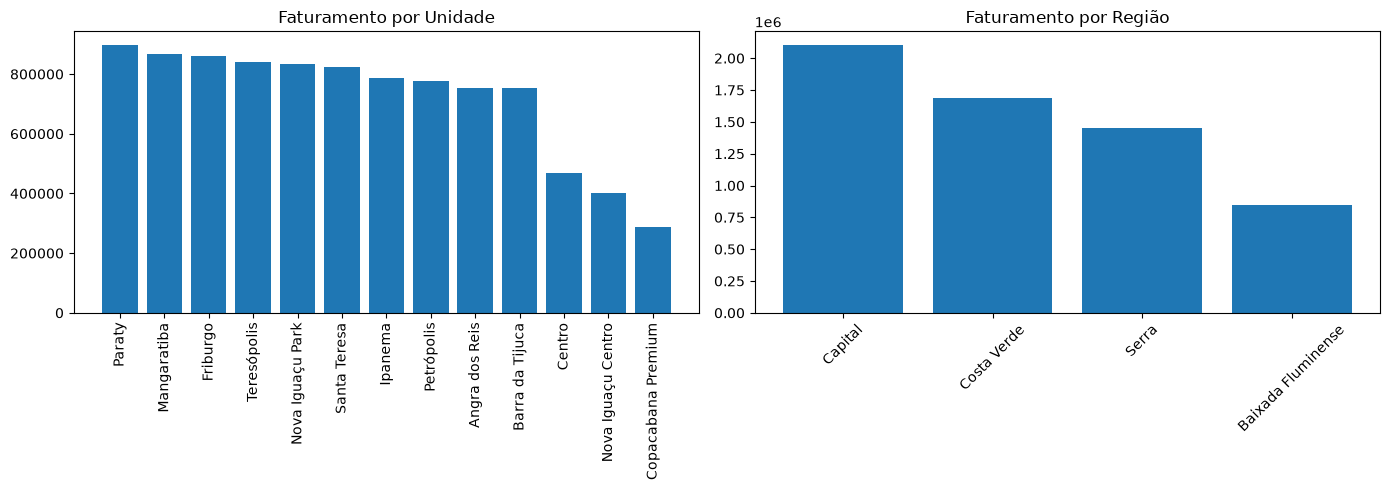

In [596]:
faturamento_unidade.index = (
    faturamento_unidade.index
    .str.replace('NaraHoteis ', '', regex=False))

fig1, eixos1 = plt.subplots(1, 2, figsize=(14, 5))

eixos1[0].bar(faturamento_unidade.index, faturamento_unidade.values)
eixos1[0].set_title('Faturamento por Unidade')
eixos1[0].tick_params(axis='x', rotation=90)

eixos1[1].bar(faturamento_regiao.index, faturamento_regiao.values)
eixos1[1].set_title('Faturamento por Região')
eixos1[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

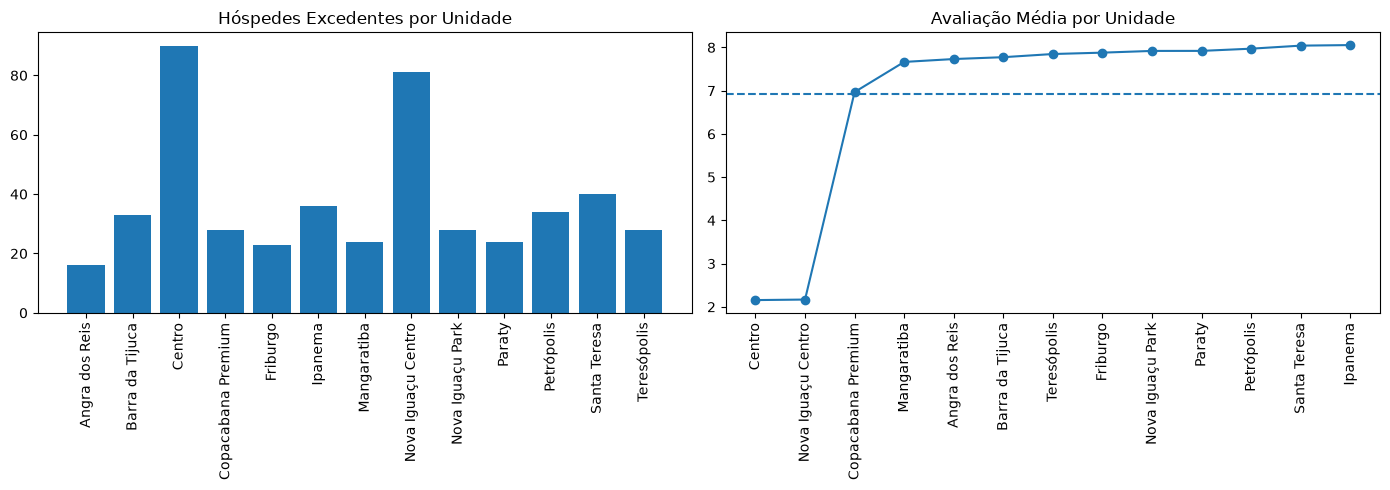

In [ ]:
fig2, eixos2 = plt.subplots(1, 2, figsize=(14, 5))

eixos2[0].bar(
    total_excedente_por_unidade.index.str.replace('NaraHoteis ', '', regex=False), 
    total_excedente_por_unidade.values)
eixos2[0].set_title('Hóspedes Excedentes por Unidade')
eixos2[0].tick_params(axis='x', rotation=90)

avaliacao_ordenada = avaliacao_unidade.sort_values()

avaliacao_ordenada.index = (
    avaliacao_ordenada.index
    .str.replace('NaraHoteis ', '', regex=False))

eixos2[1].plot(avaliacao_ordenada.index, avaliacao_ordenada.values, marker='o')
eixos2[1].axhline(y=avaliacao_unidade.mean(), linestyle='--')
eixos2[1].set_title('Avaliação Média por Unidade')
eixos2[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()